In [1]:
import pandas as pd; import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, \
ElasticNet, Lasso
from sklearn.linear_model import RidgeCV, ElasticNetCV, LassoCV
from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from patsy import dmatrix

import sys
#sys.path.append('../modules')
import ols_step_sk

# Exploration : Régression pénalisée — Ridge, Lasso, ElasticNet
**Données** : `ozone_transf.txt` (cible = `maxO3` → renommée `Y`)  
**Plan** :
1. Détermination des hyperparamètres optimaux (λ/alpha) par validation croisée
2. Tracé des chemins de régularisation (coefficients en fonction de α) pour les 3 méthodes
3. Validation sur un échantillon test (train/test split)
4. *(Section vide)* Généralisation dans une boucle de CV complète

In [ ]:
# Fichier local (ozone déjà transformé : variables qualitatives encodées, NA retirés)
don = pd.read_csv("ozone_transf.txt", header=0, sep=";", index_col=0)
don.shape

(1366, 22)

In [27]:
don.describe()

,maxO3,T6,T9,T12,T15,T18,Ne6,Ne9,Ne12,Ne15,...,Vy6,Vx9,Vy9,Vx12,Vy12,Vx15,Vy15,Vx18,Vy18,maxO3v
count,1366.000000,1366.000000,1366.000000,1366.000000,1366.000000,1366.000000,1366.000000,1366.000000,1366.000000,1366.000000,...,1366.000000,1366.000000,1366.000000,1366.000000,1366.000000,1366.000000,1366.000000,1366.000000,1366.000000,1366.000000
mean,84.920205,12.298609,16.387482,19.428697,20.345095,18.780747,5.012445,5.166179,5.332357,5.142020,...,-0.055703,-0.614080,0.066847,-0.768286,0.174452,-0.967926,0.623767,-0.598198,1.170796,84.974817
std,23.116711,3.890976,4.100004,4.897765,5.245008,5.046637,2.900902,2.549047,2.313064,2.321811,...,2.174897,2.894330,2.943046,3.395397,3.535422,3.346146,3.833651,2.879025,3.500867,23.370954
min,33.200000,-1.600000,4.500000,5.700000,5.700000,4.400000,0.000000,0.000000,0.000000,0.000000,...,-8.457234,-9.396926,-11.276311,-10.392305,-10.392305,-9.526279,-13.856406,-10.392305,-9.000000,33.200000
25%,68.000000,10.000000,13.800000,16.300000,16.800000,15.500000,2.000000,3.000000,4.000000,3.000000,...,-1.285575,-2.819078,-1.928363,-3.074680,-2.298133,-3.464102,-2.236630,-2.819078,-1.710101,68.000000
50%,80.700000,12.700000,16.700000,19.400000,20.400000,18.600000,6.000000,6.000000,6.000000,6.000000,...,0.000000,-0.684040,0.000000,-1.026060,0.000000,-1.215537,0.694593,-0.684040,1.285575,80.700000
75%,98.000000,15.100000,19.000000,22.600000,23.900000,22.000000,8.000000,7.000000,7.000000,7.000000,...,1.026060,1.285575,2.000000,1.500000,2.819078,1.389185,3.758770,1.368081,4.330127,98.000000
max,166.000000,21.700000,28.600000,33.500000,35.500000,34.100000,9.000000,9.000000,8.000000,8.000000,...,9.526279,8.863270,9.000000,10.832885,8.863270,9.526279,11.276311,9.396926,8.457234,173.000000


In [ ]:
# Suppression des lignes avec valeurs manquantes (quelques NA dans ozone_transf.txt)
lesna = pd.isna(don)
indNA = lesna.apply(any, axis=1)
don = don[~indNA]
don.shape

(1366, 22)

In [37]:
don.rename(columns={"maxO3":"Y"},inplace=True)
y = don["Y"].to_numpy()
X = don.iloc[:,1:10].to_numpy()

## Partie 1 — Détermination des alphas optimaux par validation croisée
`LassoCV` et `ElasticNetCV` cherchent automatiquement la grille d'alpha.  
`RidgeCV` n'a pas de grille automatique, on la dérive de la grille Lasso (`×100`, les normes étant différentes).

In [ ]:
cr = StandardScaler()                                       # centrer-réduire X (obligatoire avant pénalisation)
kf = KFold(n_splits=10, shuffle=True, random_state=0)       # 10 blocs de CV reproductibles

In [ ]:
# LassoCV et ElasticNetCV déterminent automatiquement leur grille d'alpha par CV
# Le Pipeline garantit que le centrage-réduction est refait à chaque fold
lassocv = LassoCV(cv=kf)                # pénalité L1 : sélection de variables (coefficients = 0)
enetcv  = ElasticNetCV(cv=kf)           # pénalité L1+L2 : l1_ratio=0.5 par défaut
pipe_lassocv = Pipeline(steps=[("cr", cr), ("lassocv", lassocv)])
pipe_enetcv  = Pipeline(steps=[("cr", cr), ("enetcv",  enetcv)])

In [40]:
pipe_lassocv.fit(X, y)  # estimation
pipe_enetcv.fit(X, y)

Pipeline(steps=[('cr', StandardScaler()),
                ('enetcv',
                 ElasticNetCV(cv=KFold(n_splits=10, random_state=0, shuffle=True)))])

In [41]:
etape_lassocv = pipe_lassocv.named_steps["lassocv"]
etape_enetcv = pipe_enetcv.named_steps["enetcv"]

In [ ]:
# Ridge n'a pas de grille automatique → on la dérive de la grille Lasso (×100)
# car Ridge utilise la norme L2 dont l'échelle est ~100× plus grande que L1
alphasridge = etape_lassocv.alphas_ * 100
ridgecv = RidgeCV(cv=kf, alphas=alphasridge)

In [53]:
pipe_ridgecv = Pipeline(steps=[("cr", cr), ("ridgecv", ridgecv)])
pipe_ridgecv.fit(X, y)

Pipeline(steps=[('cr', StandardScaler()),
                ('ridgecv',
                 RidgeCV(alphas=array([1331.16762785, 1241.451385  , 1157.78171664, 1079.7511039 ,
       1006.9794933 ,  939.11244569,  875.81940995,  816.79211299,
        761.74305828,  710.40412562,  662.52526519,  617.87327971,
        576.23068861,  537.39466877,  501.17606669,  467.39847718,
        435.89738414,  406.51935935,  379.1213151 ,  353.56980734,
        329.74038568,  307....
          8.7581941 ,    8.16792113,    7.61743058,    7.10404126,
          6.62525265,    6.1787328 ,    5.76230689,    5.37394669,
          5.01176067,    4.67398477,    4.35897384,    4.06519359,
          3.79121315,    3.53569807,    3.29740386,    3.07516987,
          2.86791372,    2.67462593,    2.49436509,    2.32625323,
          2.16947155,    2.02325643,    1.88689572,    1.75972526,
          1.64112567,    1.53051929,    1.42736741,    1.33116763]),
                         cv=KFold(n_splits=10, random_state=0, shuffle=True)))])

In [54]:
etape_ridgecv = pipe_ridgecv.named_steps["ridgecv"]

Text(0, 0.5, 'Coefficients')

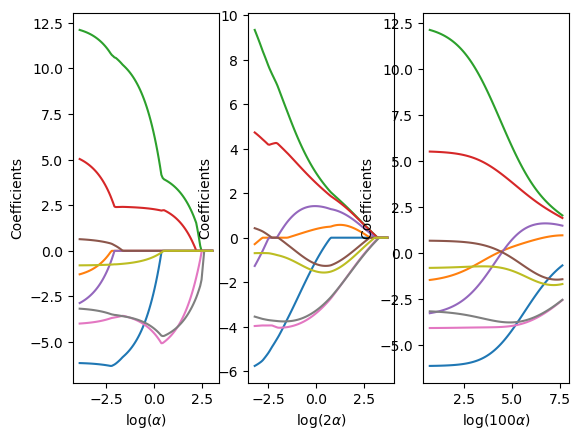

In [ ]:
## Partie 2 — Chemins de régularisation (3 méthodes côte à côte)
Pour chaque valeur d'alpha dans la grille Lasso, on ajuste les 3 modèles et on mémorise les coefficients.  
Cela permet de visualiser comment chaque variable entre/sort du modèle selon la force de pénalisation.

In [ ]:
alphas = pipe_lassocv.named_steps["lassocv"].alphas_    # grille automatique de LassoCV
coefs_lasso = []; coefs_enet = []; coefs_ridge = []
Xcr = StandardScaler().fit(X).transform(X)              # centrer-réduire X sur tout l'échantillon

for a in alphas:
    lasso = Lasso(alpha=a,      warm_start=True).fit(Xcr, y)
    enet  = ElasticNet(alpha=a*2,   warm_start=True).fit(Xcr, y)   # ×2 car ElasticNet répartit sur L1+L2
    ridge = Ridge(alpha=a*100)              .fit(Xcr, y)            # ×100 car norme L2 à échelle différente
    coefs_lasso.append(lasso.coef_)
    coefs_enet.append(enet.coef_)
    coefs_ridge.append(ridge.coef_)

# Tracé comparatif sur 3 sous-graphes
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
ax1.plot(np.log(alphas), coefs_lasso);  ax1.set_title("Lasso");     ax1.set_xlabel(r"$\log(\alpha)$"); ax1.set_ylabel("Coefficients")
ax2.plot(np.log(2*alphas), coefs_enet); ax2.set_title("ElasticNet"); ax2.set_xlabel(r"$\log(2\alpha)$")
ax3.plot(np.log(100*alphas), coefs_ridge); ax3.set_title("Ridge");   ax3.set_xlabel(r"$\log(100\alpha)$")
plt.tight_layout()
plt.show()

In [56]:
# donner les alpha/lamba optimaux pour chaque méthode après CV
print("Lasso: ", round(etape_lassocv.alpha_,4))
print("ElasticNet: ", round(etape_enetcv.alpha_,4))
print("Ridge: ", round(etape_ridgecv.alpha_,4))

Lasso:  0.2169
ElasticNet:  0.0266
Ridge:  16.4113


## Partie 3 — Validation sur un échantillon test (train/test split)
On sépare manuellement 45 individus pour l'apprentissage et 5 pour le test, puis on ajuste `LassoCV` sur l'apprentissage et on prédit sur le test.  
> ⚠️ Ce découpage est arbitraire et ne remplace pas une vraie validation croisée (cf. Partie 4).

In [49]:
Xapp = don.iloc[0:45,1:10].to_numpy()
Xnew = don.iloc[45:50,1:10].to_numpy()
yapp = np.ravel(don.iloc[0:45,:1])
ynew = np.ravel(don.iloc[45:50,:1])

In [50]:
kf = KFold(n_splits=10, shuffle=True, random_state=0)
cr = StandardScaler()
lassocv = LassoCV(cv=kf)
pipe_lassocv = Pipeline(steps=[("cr", cr), ("lassocv", lassocv)])
pipe_lassocv.fit(Xapp,yapp)

Pipeline(steps=[('cr', StandardScaler()),
                ('lassocv',
                 LassoCV(cv=KFold(n_splits=10, random_state=0, shuffle=True)))])

In [51]:
pipe_lassocv.predict(Xnew)

array([61.63889103, 75.89512299, 74.19800701, 77.19245776, 73.79707303])

## Partie 4 — À compléter : boucle de CV complète (toutes méthodes)
À reprendre depuis `ComparaisonReg_final.ipynb` pour intégrer Lasso/ElasticNet/Ridge/Arbre/Forêt/PCR/PLS dans une seule boucle de validation croisée.